# 2D transient heat conduction (implicit Euler) — FOM + ROM

This example follows the same workflow as other scikit-rom examples:
1) Offline full-order solves to generate snapshots
2) POD basis generation (SVD) on mean-subtracted training data
3) Online reduced-order solves and error/speed-up evaluation


## Environment setup

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))


In [14]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")
from skrom.rom.rom_error_est_t import *


In [3]:
import sci_mplstyle_package

## Full-order simulation (offline snapshots)

In [4]:
generate = True
if generate:
    sim = master.fom_simulation(num_snapshots=16)
    sim.run_simulation()


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Snap 1/32 params=[1.862171   3.58096441]
Snap 2/32 params=[3.78473358 0.36854761]
Snap 3/32 params=[3.00175439 4.60191377]
Snap 4/32 params=[0.31116481 1.52534439]
Snap 5/32 params=[1.28107545 4.17904809]
Snap 6/32 params=[3.18454422 2.19614647]
Snap 7/32 params=[4.81329742 2.67957699]
Snap 8/32 params=[2.1418205  0.87333987]
Snap 9/32 params=[2.30311277 4.79685743]
Snap 10/32 params=[4.68505035 1.56490939]
Snap 11/32 params=[3.6329108  3.30802925]
Snap 12/32 params=[0.78919621 0.25099113]
Snap 13/32 params=[0.45866705 2.95338944]
Snap 14/32 params=[2.82151081 0.99001906]
Snap 15/32 params=[4.2576568  3.98322714]
Snap 16/32 params=[1.43305488 2.15745876]
Snap 17/32 params=[0.85124706 0.45706963]
Snap 18/32 params=[4.49767167 3.59073545]
Snap 19/32 params=[3.65592803 1.40954146]
Snap 20/32 params=[2.45857816 4.54267491]
Snap 21/32 params=[1.92241024 2.10333423]
Snap 22/32 params=[3.12004048 3.96593374]
Snap 23/32 params=[3.80961183 1.03493271]
Snap 24/32 params=[0.16107502 2.89577785]
S

## POD basis (stack all time instants across training parameters)

In [5]:
# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

# Training snapshots and mean field
T_train = rom_data.fos_solutions[rom_data.train_mask]          # (n_train, nt, Nh)
T_ref  = T_train[:,0:1,:] 

[load_rom_data] loaded from d:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\tests_\heat_transfer\dynamic\problem_transient_heat_2d\ROM_data


In [6]:
T_train_ms = T_train - T_ref  

Number of modes selected: 10
Selected modes: 10  | Nh: 676


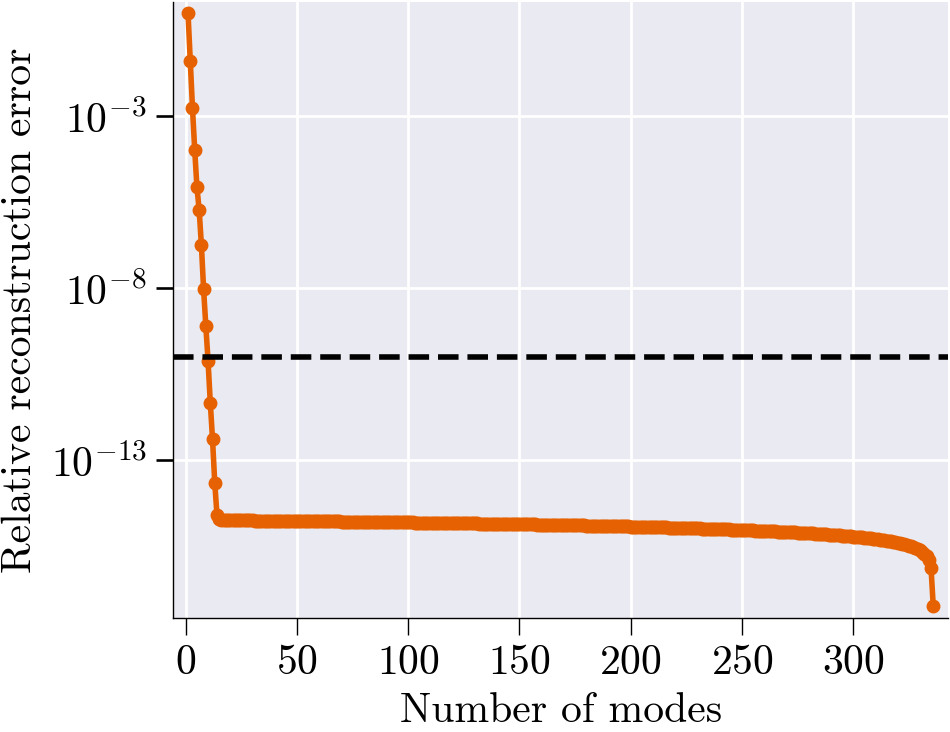

In [7]:
# Stack time and parameter snapshots into a 2D matrix for SVD
X = T_train_ms.reshape(-1, T_train_ms.shape[-1])              # (n_train*nt, Nh)

plt.rcParams['lines.markersize'] = 6
plt.rcParams['lines.linewidth'] = 2.0
n_sel, U = svd_mode_selector(X, tolerance=1e-10, modes=True)
V_sel = U[:, :n_sel]
print('Selected modes:', n_sel, ' | Nh:', V_sel.shape[0])


## ROM simulation (online)

In [8]:
rom = master.rom_simulation(V_sel=V_sel, n_sel=n_sel, train_ref=T_ref, test_ref=T_ref)
rom_error, speed_up = rom.run_rom_simulation()
print('Mean ROM error (%):', np.mean(rom_error))
print('Mean speed-up:', np.mean(speed_up))


[load_rom_data] loaded from d:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\tests_\heat_transfer\dynamic\problem_transient_heat_2d\ROM_data
Snap 1/32 params=[0.85124706 0.45706963]
Snap 2/32 params=[4.49767167 3.59073545]
Snap 3/32 params=[3.65592803 1.40954146]
Snap 4/32 params=[2.45857816 4.54267491]
Snap 5/32 params=[1.92241024 2.10333423]
Snap 6/32 params=[3.12004048 3.96593374]
Snap 7/32 params=[3.80961183 1.03493271]
Snap 8/32 params=[0.16107502 2.89577785]
Snap 9/32 params=[0.71216425 1.86134399]
Snap 10/32 params=[4.33050404 4.99905404]
Snap 11/32 params=[2.56938466e+00 5.76488674e-05]
Snap 12/32 params=[1.40137197 3.13952285]
Snap 13/32 params=[2.08958663 0.69543591]
Snap 14/32 params=[3.25911336 2.56146799]
Snap 15/32 params=[4.86682795 2.43827486]
Snap 16/32 params=[1.24760963 4.30484269]
Mean ROM error (%): 5.368922993304109e-08
Mean speed-up: 6.994126762226873


## Quick visualization (one test case, final time)

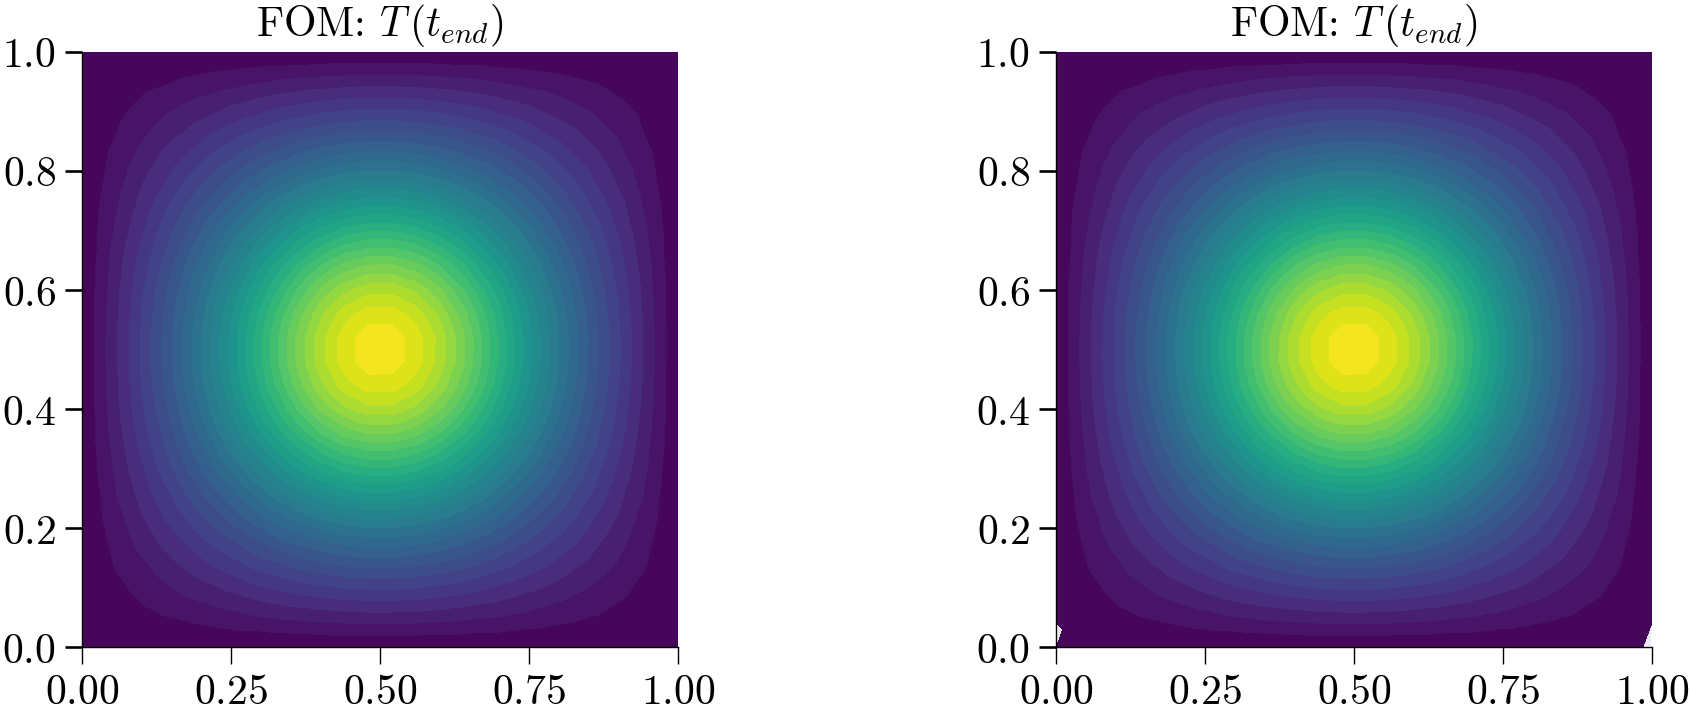

In [13]:
i = 0
Tf = rom.fos_test_data[i][-1, :]
Tr = rom.rom_solutions[i][-1, :]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].tricontourf(rom.mesh.p[0], rom.mesh.p[1], Tf, levels=32)
ax[0].set_title('FOM: $T\,(t_{end})$')
ax[0].set_aspect('equal')

ax[1].tricontourf(rom.mesh.p[0], rom.mesh.p[1], Tr, levels=32)
ax[1].set_title('FOM: $T\,(t_{end})$')
ax[1].set_aspect('equal')
plt.tight_layout()
plt.show()


## ROM Quality stats

In [17]:
matrix = compute_rom_error_metrics_flat(rom_data.fos_solutions[rom_data.test_mask] , np.asarray(rom.rom_solutions))

In [18]:
# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

ROM Accuracy Report

Global Errors:
L2 Error:                        5.4801e-09
Relative L2 Error:               5.8340e-10
L∞ Error:                        3.5270e-10
Relative L∞ Error:               1.2288e-09
RMSE:                            1.1499e-11
MAE:                             4.7092e-12

Statistical Fit:
R² Score:                        1.0000
Explained Variance:              1.0000

Error Distribution (absolute):
Median Abs Error:                1.7088e-12
95th Percentile Abs Error:       1.8088e-11

Time/Parameter-Dependent Errors:
Average Relative L2 over samples:        5.1595e-10
Max Relative L2 over samples:            3.0886e-09
Min Relative L2 over samples:            0.0000e+00
————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————


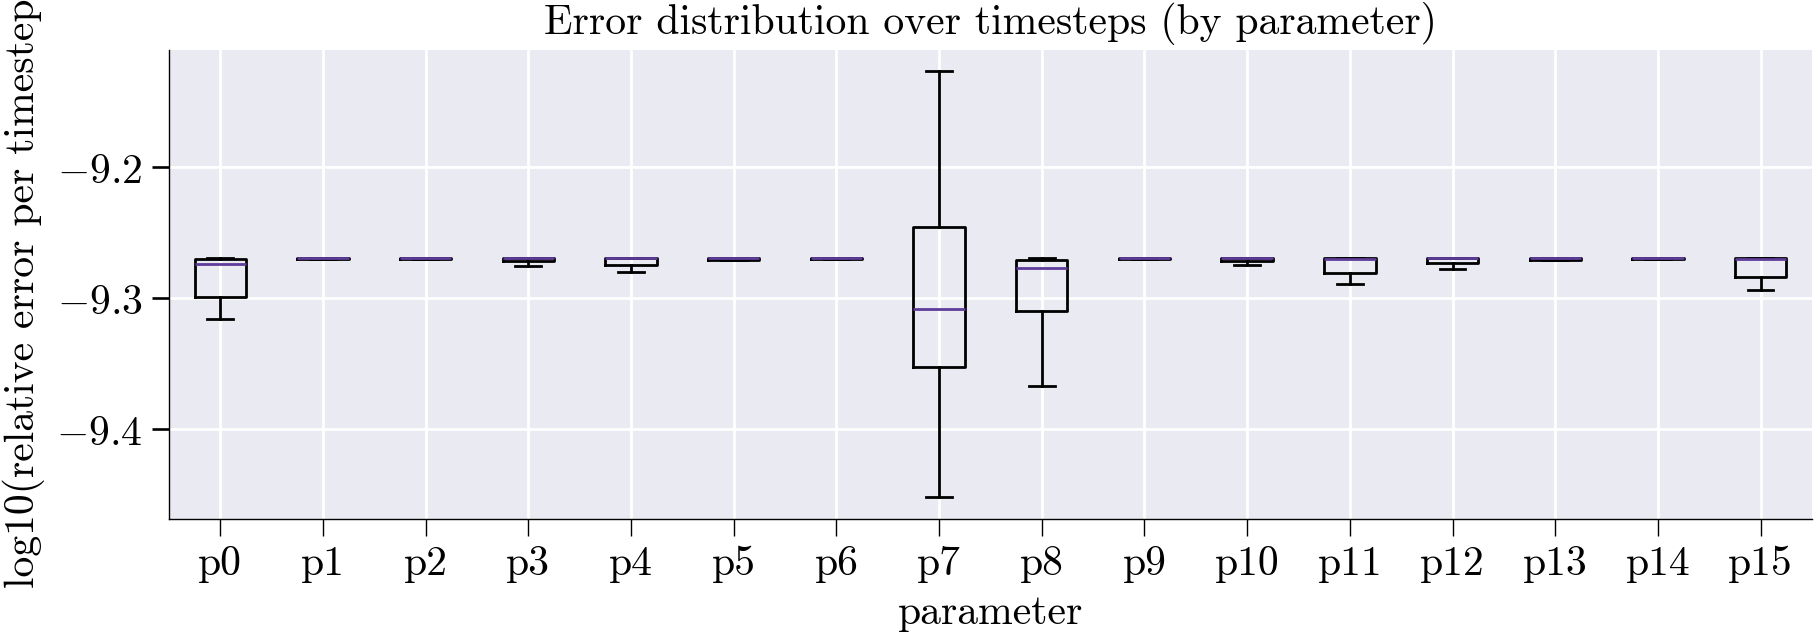

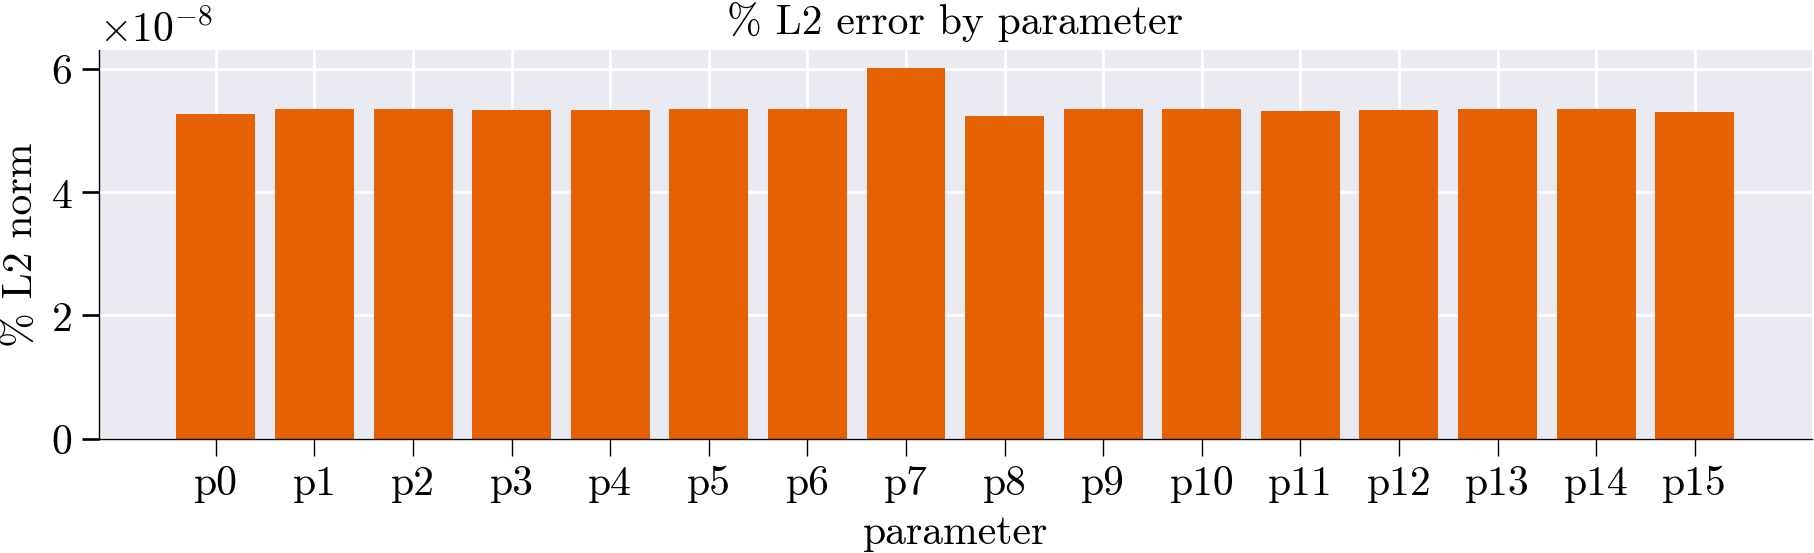

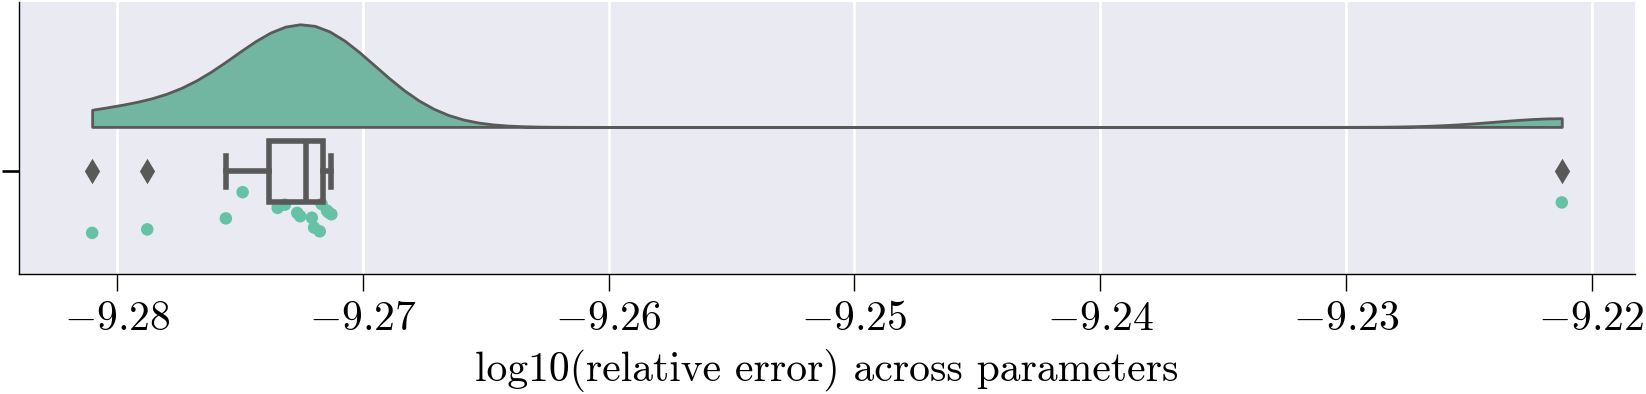

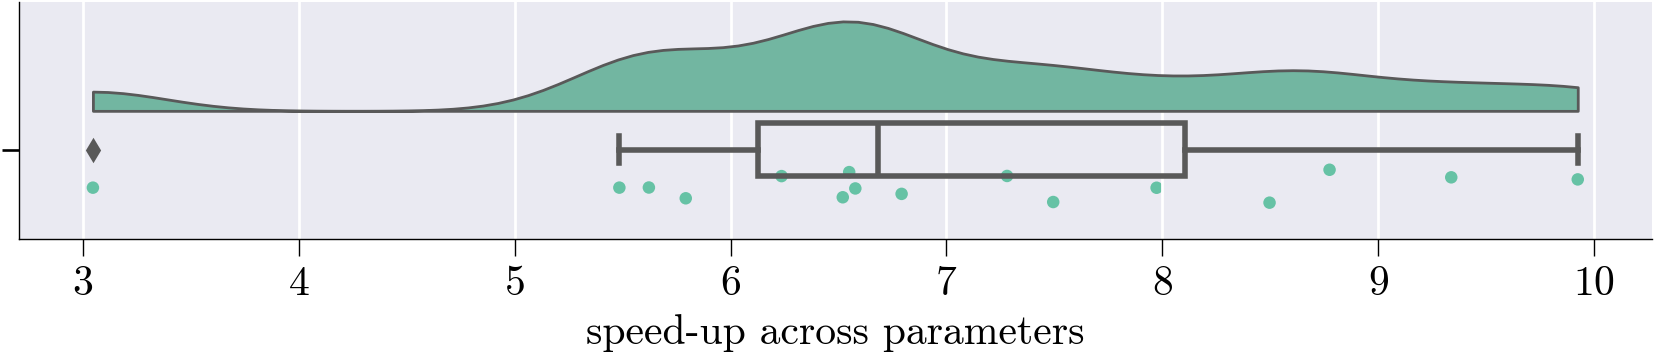

In [20]:
out = plot_rom_param_diagnostics_t(
    rom_data.fos_solutions[rom_data.test_mask],
    np.asarray(rom.rom_solutions),
    l2_per_param=rom_error,          # (p,)
    speedup_per_param=speed_up, # (p,)
    param_labels=[f"p{i}" for i in range(rom_data.fos_solutions[rom_data.test_mask].shape[0])],
    use_raincloud=True,
)
